In [1]:
# ---- Local setup (replaces Google Colab drive mount) ----
import os

# Working directory on the local machine (adjust if needed)
project_dir = r"D:\Desk\Brain Graph\bestmellah\DHGFormer"
os.chdir(project_dir)


In [2]:
# ---- Package installation (run once in your local environment / terminal) ----
# The original notebook installed these inside Google Colab using Colab-specific wheel indexes.
# On a local machine, install the matching versions yourself (uncomment if needed):

# !pip install torch==1.11.0 torchvision==0.12.0 torchaudio==0.11.0
# !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://pytorch-geometric.com/whl/torch-1.11.0+cu102.html
# !pip install torch-geometric==2.2.0


In [3]:
# ComBat: using the official 'neuroCombat' package
# !pip install neuroCombat


In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from neuroCombat import neuroCombat
import pandas as pd
from sklearn import svm
import joblib
import openpyxl
from openpyxl import load_workbook
import os
import scipy.io as scio
import argparse
import numpy as np
import time
import torch
import torch.utils.data
import torch.nn as nn
import torch.optim as optim
from torch.utils.data.dataset import Dataset
from torch.autograd import Variable
from torchvision import datasets, transforms
from torchvision.utils import make_grid , save_image
import torchvision.utils as vutils
from os.path import join
from os import listdir
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import DataLoader
from collections import OrderedDict
import nibabel as nib
import matplotlib.pyplot as plt
import cv2 as cv
from os import path
import shutil
import scipy.stats
import scipy.ndimage
import random
import torch.nn.init as init
import torch.nn.functional as F
import sys
import math
from functools import reduce
import operator
from scipy.interpolate import interp1d
from torch.optim import lr_scheduler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.feature_selection import RFE


def get_index(lst=None, item=''):
	return [i for i in range(len(lst)) if lst[i] == item]



def get_ids(num_subjects=None,dir_path=''):
	"""
	return:
		subject_IDs    : list of all subject IDs
	"""
	subject_IDs = np.genfromtxt(os.path.join(dir_path, 'subject_IDs.txt'), dtype=str)

	if num_subjects is not None:
		subject_IDs = subject_IDs[:num_subjects]

	return subject_IDs

def save_model(net,path, name_net):

  # This fucntion is used to save a specific model

    path_net =  path + '/' + name_net + '.pth'
    torch.save(net.cpu().state_dict(), path_net)
    if torch.cuda.is_available():
        net.cuda()

def load_model(net, path, name_net):

  # This function is used to load a specific model we saved before

    path_net =  path + '/' + name_net + '.pth'
    net.load_state_dict(torch.load(path_net))

    return net



In [5]:
########################################### Load Data ###############################################
#####################################################################################################
#####################################################################################################
combat = True    # True or False


if combat == False:
  save_combat = '/without_ComBat/'
else:
  save_combat = '/with_ComBat/'

# ---- Local paths ----
smri_csv_path = r"D:\Desk\Brain Graph\bestmellah\DHGFormer\abide_smri.csv"
phenotypic_csv_path = r"D:\Desk\Brain Graph\lets start\DHGFormer\data\ABIDE_pcp\Phenotypic_V1_0b_preprocessed1.csv"

save_path = project_dir + '/save_models/sMRI' + save_combat
if not os.path.exists(save_path):
  os.makedirs(save_path)

k_fold = 5
new_number_features = 1435
scaler = True

# ---- Read the pre-extracted sMRI feature table ----
smri_df = pd.read_csv(smri_csv_path)
subject_IDs = smri_df['subject_id'].astype(str).tolist()
number_samples = len(subject_IDs)
useless_samples = []   # no .stats parsing failures possible with the pre-built csv

# ---- Read the ABIDE phenotypic table (label / site / age / gender only) ----
pheno_df = pd.read_csv(phenotypic_csv_path)
pheno_df['FILE_ID'] = pheno_df['FILE_ID'].astype(str)
pheno_df = pheno_df.set_index('FILE_ID')

labels = np.zeros(number_samples)
genders = np.zeros((number_samples, 1))
ages = np.zeros((number_samples, 1))
sites = []

for i in range(number_samples):
  subject_name = subject_IDs[i]
  row = pheno_df.loc[subject_name]
  labels[i] = int(row['DX_GROUP']) - 1          # DX_GROUP: 1=Autism, 2=Control -> 0/1
  genders[i] = int(row['SEX'])                  # SEX already coded 1=male, 2=female
  ages[i] = float(row['AGE_AT_SCAN'])
  sites.append(str(row['SITE_ID']).replace(' ', ''))

unique_sites = list(np.unique(np.array(sites)))


In [6]:
############################################### Load sMRI ###############################################################
############################################### Load sMRI ###############################################################
############################################### Load sMRI ###############################################################
############################################### Load features from the pre-built csv

feature_cols = [c for c in smri_df.columns if c != 'subject_id']
print(len(feature_cols))
sMRI_features = smri_df[feature_cols].values.astype(float)

# ---- Impute missing values (some FreeSurfer regions can be missing/NaN for a few subjects) ----
nan_mask = np.isnan(sMRI_features)
if nan_mask.any():
  col_median = np.nanmedian(sMRI_features, axis=0)
  inds = np.where(nan_mask)
  sMRI_features[inds] = np.take(col_median, inds[1])
  print('Filled', int(nan_mask.sum()), 'missing values with column medians')

# ---- Drop zero-variance columns (they cause divide-by-zero -> NaN inside ComBat) ----
col_std = sMRI_features.std(axis=0)
keep_cols = col_std > 0
if (~keep_cols).any():
  print('Dropping', int((~keep_cols).sum()), 'zero-variance columns')
  sMRI_features = sMRI_features[:, keep_cols]
  feature_cols = [c for c, k in zip(feature_cols, keep_cols) if k]

if scaler == True:
  sMRI_features = StandardScaler().fit_transform(sMRI_features)

print('sMRI feature matrix shape:', sMRI_features.shape)


2386
Filled 594 missing values with column medians
Dropping 191 zero-variance columns
sMRI feature matrix shape: (1009, 2195)


In [7]:
############################################### Combat ###############################################################
############################################### Combat ###############################################################
############################################### Combat ###############################################################
if combat == True:
	batch = []
	for i in range(len(sites)):
		batch.append(get_index(lst=unique_sites, item=sites[i])[0]+1)

	combat_labels = []
	combat_genders = []
	combat_ages = []
	for i in range(len(labels)):
		combat_labels.append(labels[i] + 1)
		combat_genders.append(genders[i])
		combat_ages.append(ages[i])

	new_all_samples_feature = sMRI_features.T
	covars = {}
	covars['batch'] = batch
	covars['labels'] = combat_labels
	covars['genders'] = combat_genders
	covars['ages'] = combat_ages
	covars = pd.DataFrame(covars)

	# To specify names of the variables that are categorical:
	categorical_cols = ['labels', 'genders']
	# To specify the name of the variable that encodes for the scanner/batch covariate:
	batch_col = 'batch'
	continuous_cols = ['ages']
	# Harmonization step:
	new_all_samples_feature = neuroCombat(dat=new_all_samples_feature,
										  covars=covars,
										  batch_col=batch_col,
										  categorical_cols=categorical_cols,
											continuous_cols=continuous_cols)["data"]
	sMRI_features = new_all_samples_feature.T

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


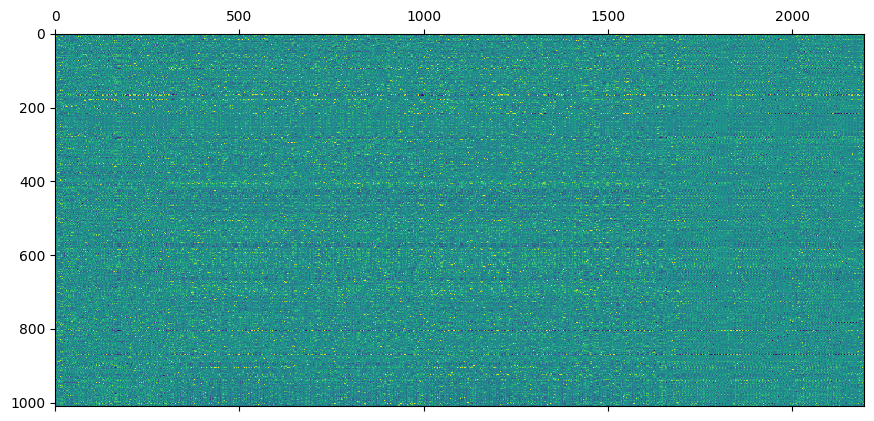

In [8]:
plt.matshow(sMRI_features, vmin=-4, vmax=4)
plt.show()

In [9]:
import torch
import yaml
from dataloader import init_dataloader

with open(r"D:\Desk\Brain Graph\bestmellah\DHGFormer\setting\abide_DHGFormer.yaml", "r") as f:
    config = yaml.load(f, Loader=yaml.Loader)

(train_dataloader, val_dataloader, test_dataloader), node_size, node_feature_size, timeseries, smri_size = init_dataloader(config['data'])

train_idx = list(train_dataloader.dataset.indices)
val_idx   = list(val_dataloader.dataset.indices)
test_idx  = list(test_dataloader.dataset.indices)

k_fold = 1
dist_train = {'1': train_idx}
dist_validation = {'1': val_idx}
dist_test = {'1': test_idx}

In [10]:
import torch.nn as nn
import torch_geometric as tg
from torch_geometric.nn import global_mean_pool

############################################### GCN model (graph classification) #########################################
############################################### GCN model (graph classification) #########################################
############################################### GCN model (graph classification) #########################################
# CHANGED: previously this was a POPULATION graph GCN (one big graph, one node PER SUBJECT,
# node-level classification). Now every subject is its OWN graph (nodes = that subject's
# brain regions), so this is GRAPH classification: the conv layers build region-level
# (node-level) embeddings, global_mean_pool collapses each subject's graph into a single
# vector, and a linear layer classifies that vector.
class GCN(nn.Module):
    def __init__(self, in_c, hid_c, out_c, K, dropout_rate, normalize=True):
        """
        :param in_c: int, number of input channels (node/region feature size).
        :param hid_c: int, number of hidden channels.
        :param out_c: int, number of output classes.
        :param K:
        """
        super(GCN, self).__init__()
        self.normalize = normalize

        self.conv1 = tg.nn.ChebConv(in_c, hid_c, K, normalization='sym', bias=True)
        self.conv2 = tg.nn.ChebConv(hid_c, hid_c, K, normalization='sym', bias=True)
        self.conv3 = tg.nn.ChebConv(hid_c, hid_c, K, normalization='sym', bias=True)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hid_c, out_c)
        self.softmax = nn.LogSoftmax(dim=1)


    def forward(self, data, edge_index, edgenet_input, batch):

        edge_weight = torch.squeeze(edgenet_input)
        h = self.relu(self.dropout(self.conv1(data, edge_index, edge_weight)))
        h = self.relu(self.dropout(self.conv2(h, edge_index, edge_weight)))
        h = self.relu(self.dropout(self.conv3(h, edge_index, edge_weight)))

        h = global_mean_pool(h, batch)   # one vector per subject-graph
        h = self.classifier(h)

        return self.softmax(h)


In [11]:
import torch_geometric as tg

############################################### Per-subject brain graphs ###################################################
############################################### Per-subject brain graphs ###################################################
############################################### Per-subject brain graphs ###################################################
# CHANGED: this used to build a POPULATION graph (each SUBJECT = one node, edges from
# phenotypic similarity such as age/site/gender). The goal now is GRAPH classification:
# each SUBJECT = one graph, and the nodes of that graph are the subject's own brain
# regions (parsed straight out of the FreeSurfer column names in abide_smri.csv, e.g.
# "lh_G_front_sup_ThickAvg", "aseg_Left-Amygdala_Volume_mm3", "wmparc_wm-lh-insula_normMean").
# Each REGION becomes one node, and the node's feature vector is that region's own set of
# FreeSurfer metrics (volume, thickness, surface area, curvature, ...) for that subject -
# NOT a single RFE-selected scalar like before. Whole-brain "_Measure_" columns (e.g.
# aseg_Measure_ICV) are skipped since they don't belong to a single region.

DESTRIEUX_METRICS = ['CurvInd', 'FoldInd', 'GausCurv', 'GrayVol', 'MeanCurv', 'NumVert', 'SurfArea', 'ThickAvg', 'ThickStd']
# SEGSTATS_METRICS  = ['Index', 'NVoxels', 'SegId', 'Volume_mm3', 'normMax', 'normMean', 'normMin', 'normRange', 'normStdDev']
SEGSTATS_METRICS  = ['NVoxels', 'Volume_mm3', 'normMax', 'normMean', 'normMin', 'normRange', 'normStdDev']
ALL_METRIC_SUFFIXES = DESTRIEUX_METRICS + SEGSTATS_METRICS

def parse_region_columns(cols):
    """
    Groups sMRI feature columns (FreeSurfer aseg / lh_/rh_ Destrieux / wmparc naming) into
    brain REGIONS, each carrying its own small set of metrics.
        cols : list of column names (e.g. feature_cols, after the zero-variance filter)
    return:
        region_to_cols : OrderedDict region_name -> list of (metric_name, column_index)
    """
    region_to_cols = OrderedDict()
    for idx, col in enumerate(cols):
        if '_Measure_' in col:
            continue  # whole-brain summary stat, not a single region - skip
        matched_metric = None
        for metric in ALL_METRIC_SUFFIXES:
            suffix = '_' + metric
            if col.endswith(suffix):
                matched_metric = metric
                region_name = col[: -len(suffix)]
                break
        if matched_metric is None:
            continue  # doesn't follow the expected region_metric naming - skip
        region_to_cols.setdefault(region_name, []).append((matched_metric, idx))
    return region_to_cols


def build_region_node_features(feature_matrix, region_to_cols, region_names, node_feature_dim):
    """
        feature_matrix : (num_subjects x num_feature_columns), e.g. sMRI_features after ComBat/scaling
    return:
        (num_subjects x num_regions x node_feature_dim) - each subject's own metrics per region
        (regions with fewer than node_feature_dim available metrics are zero-padded)
    """
    num_subjects = feature_matrix.shape[0]
    num_regions = len(region_names)
    out = np.zeros((num_subjects, num_regions, node_feature_dim), dtype=np.float32)
    for r, region_name in enumerate(region_names):
        for m, (metric_name, col_idx) in enumerate(region_to_cols[region_name]):
            out[:, r, m] = feature_matrix[:, col_idx]
    return out


def region_canonical_values(feature_matrix, region_to_cols, region_names,
                             preferred_metrics=('GrayVol', 'Volume_mm3', 'NVoxels')):
    """
    One representative value per region (prefers a size/volume-type metric), used ONLY to
    build the k-NN correlation graph topology below - not used as the node feature itself.
        feature_matrix : (num_subjects x num_feature_columns)
    return:
        (num_subjects x num_regions)
    """
    num_subjects = feature_matrix.shape[0]
    num_regions = len(region_names)
    out = np.zeros((num_subjects, num_regions), dtype=np.float32)
    for r, region_name in enumerate(region_names):
        cols = region_to_cols[region_name]
        metric_names = [m for m, _ in cols]
        chosen = 0
        for p in preferred_metrics:
            if p in metric_names:
                chosen = metric_names.index(p)
                break
        _, col_idx = cols[chosen]
        out[:, r] = feature_matrix[:, col_idx]
    return out


# Edge choice: same "structural covariance" idea as before, but now built between REAL
# anatomical regions instead of RFE-selected scalar features. Two regions are connected if
# their (canonical) values co-vary across the TRAINING subjects (Pearson correlation),
# keeping each region's top-k strongest connections. Topology is shared across subjects in
# a fold (built from train subjects only, to avoid leakage); node features stay per-subject.

k_neighbors_per_node = 8   # how many edges to keep per brain-region node

def build_region_graph(region_canonical_train, k=k_neighbors_per_node):
    """
        region_canonical_train : (num_train_subjects x num_regions) matrix, TRAIN SET ONLY
    return:
        edge_index  : (2, E) torch.long   -- shared graph topology (same for every subject)
        edge_weight : (E,)   torch.float  -- abs(correlation) between the two connected regions
    """
    num_regions = region_canonical_train.shape[1]
    corr = np.corrcoef(region_canonical_train.T)
    corr = np.nan_to_num(corr, nan=0.0)
    np.fill_diagonal(corr, 0.0)

    src, dst, w = [], [], []
    for node in range(num_regions):
        neighbors = np.argsort(-np.abs(corr[node]))[:k]
        for nb in neighbors:
            src.append(node)
            dst.append(int(nb))
            w.append(abs(corr[node, nb]))

    edge_index = np.array([src, dst], dtype=np.int64)
    edge_weight = np.array(w, dtype=np.float32)

    # make the graph undirected
    edge_index = np.concatenate([edge_index, edge_index[::-1, :]], axis=1)
    edge_weight = np.concatenate([edge_weight, edge_weight], axis=0)

    return torch.from_numpy(edge_index), torch.from_numpy(edge_weight)


def build_subject_graph_list(region_node_features, labels_onehot, edge_index, edge_weight):
    """
    Build one PyG graph (Data object) PER SUBJECT.
        region_node_features : (num_subjects x num_regions x node_feature_dim) -- each
                                subject's own multi-metric value per region (node feature)
        labels_onehot         : (num_subjects x 2)
        edge_index/edge_weight : shared graph topology from build_region_graph()
    return:
        graph_list : list of torch_geometric.data.Data, one graph per subject, same order as subjects
    """
    graph_list = []
    for s in range(region_node_features.shape[0]):
        x = torch.from_numpy(region_node_features[s]).float()                  # (num_regions, node_feature_dim)
        y = torch.tensor([int(np.argmax(labels_onehot[s]))], dtype=torch.long)  # class index for this subject
        g = tg.data.Data(x=x, edge_index=edge_index, edge_attr=edge_weight.unsqueeze(1), y=y)
        graph_list.append(g)
    return graph_list


# ---- parse the real brain regions out of the sMRI feature columns ----
region_to_cols = parse_region_columns(feature_cols)
region_names = list(region_to_cols.keys())
num_regions = len(region_names)
node_feature_dim = max(len(v) for v in region_to_cols.values())
print('Parsed', num_regions, 'brain regions, node feature dim =', node_feature_dim)

all_region_node_features = build_region_node_features(sMRI_features, region_to_cols, region_names, node_feature_dim)
all_region_canonical = region_canonical_values(sMRI_features, region_to_cols, region_names)


GCN_labels = np.zeros((number_samples - len(useless_samples), 2))
for i in range(len(labels)):
    if labels[i] == 1:
        GCN_labels[i,0] = 1
    else:
        GCN_labels[i,1] = 1


Parsed 259 brain regions, node feature dim = 9


In [12]:
data = {}
for fold in range(1, k_fold+1):
  edge_index, edge_weight = build_region_graph(all_region_canonical[dist_train[str(fold)]])
  graph_list = build_subject_graph_list(all_region_node_features, GCN_labels, edge_index, edge_weight)

  data[str(fold)] = graph_list   # list of per-subject graphs, in the same order as subject_IDs/labels


In [13]:
############################################### Train, validaiton, test pipelines ###############################################################
############################################### Train, validaiton, test pipelines ###############################################################
############################################### Train, validaiton, test pipelines ###############################################################
# CHANGED: all_data is now a LIST OF PER-SUBJECT GRAPHS (see the "Per-subject brain graphs"
# cell) instead of one big population graph + a dense feature matrix. fold_train_index /
# fold_validation_index / fold_test_index still work exactly as before: they are lists of
# subject indices, just now used to pick WHICH GRAPHS go into each mini-batch, via PyG's
# DataLoader.
from torch_geometric.loader import DataLoader as PyGDataLoader

def _make_loader(all_data, indices, batch_size, shuffle):
    subset = [all_data[i] for i in indices]
    return PyGDataLoader(subset, batch_size=batch_size, shuffle=shuffle)


def train_GCN(args, model, all_data, fold_train_index, fold_validation_index, fold_test_index, scheduler):

    model.train()
    loader = _make_loader(all_data, fold_train_index, args.batch_size, shuffle=True)

    target_list, out_list = [], []
    total_loss, n_batches = 0.0, 0
    for batch in loader:
        if args.cuda:
            batch = batch.cuda()

        scheduler.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        cross_loss = torch.nn.functional.nll_loss(out, batch.y)  # only train set will be included
        cross_loss.backward()
        scheduler.step()

        total_loss += cross_loss.item()
        n_batches += 1
        out_list.append(torch.max(out, 1)[1].cpu().numpy())
        target_list.append(batch.y.cpu().numpy())

    target = np.concatenate(target_list, axis=0)
    out = np.concatenate(out_list, axis=0)
    train_loss = total_loss / max(n_batches, 1)

    ############################## validation and test ################################################################################
    val_target, val_out, val_loss = validation_GCN(args, model, all_data, fold_validation_index)
    test_target, test_out, test_out_prob, test_loss = test_GCN(args, model, all_data, fold_test_index)

    return model, target, out, train_loss, val_target, val_out, val_loss, test_target, test_out, test_out_prob, test_loss


def validation_GCN(args, model, all_data, fold_validation_index):

    model.eval()
    loader = _make_loader(all_data, fold_validation_index, args.batch_size, shuffle=False)

    target_list, out_list = [], []
    total_loss, n_batches = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            if args.cuda:
                batch = batch.cuda()

            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            cross_loss = torch.nn.functional.nll_loss(out, batch.y)

            total_loss += cross_loss.item()
            n_batches += 1
            out_list.append(torch.max(out, 1)[1].cpu().numpy())
            target_list.append(batch.y.cpu().numpy())

    target = np.concatenate(target_list, axis=0)
    out = np.concatenate(out_list, axis=0)
    val_loss = total_loss / max(n_batches, 1)

    return target, out, val_loss


def test_GCN(args, model, all_data, fold_test_index):

    model.eval()
    loader = _make_loader(all_data, fold_test_index, args.batch_size, shuffle=False)

    target_list, out_list, prob_list = [], [], []
    total_loss, n_batches = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            if args.cuda:
                batch = batch.cuda()

            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            cross_loss = torch.nn.functional.nll_loss(out, batch.y)

            total_loss += cross_loss.item()
            n_batches += 1
            out_prob = torch.exp(out)
            out_list.append(torch.max(out, 1)[1].cpu().numpy())
            target_list.append(batch.y.cpu().numpy())
            prob_list.append(out_prob.cpu().detach().numpy())

    target = np.concatenate(target_list, axis=0)
    out = np.concatenate(out_list, axis=0)
    out_prob = np.concatenate(prob_list, axis=0)
    test_loss = total_loss / max(n_batches, 1)

    return target, out, out_prob, test_loss


In [14]:
########################################### Training setting ################################################
########################################### Training setting ################################################
########################################### Training setting ################################################

parser = argparse.ArgumentParser()
parser.add_argument('--ngpu', type=int, default=1)
parser.add_argument('--nEpochs', type=int, default=40)
parser.add_argument('--start-epoch', default=0, type=int, metavar='N',
                    help='manual epoch number (useful on restarts)')
parser.add_argument('--weight-decay', '--wd', default=1e-8, type=float,
                    metavar='W', help='weight decay (default: 1e-8)')
parser.add_argument('--no-cuda', action='store_true')
parser.add_argument('--opt', type=str, default='adam')
parser.add_argument('--lr', type=str, default=8e-4)
parser.add_argument('--seed', type=int, default=1)
parser.add_argument('--cheby_order_K', type=int, default=2)
# CHANGED: input_dimension is now the NODE feature size - each brain-region node carries
# its own set of FreeSurfer metrics (volume, thickness, area, curvature, ...), so this is
# node_feature_dim (computed while parsing the region columns above), not the whole
# subject's feature-vector length like before.
parser.add_argument('--input_dimension', type=int, default=node_feature_dim)
parser.add_argument('--hidden_dimension', type=int, default=128)
parser.add_argument('--output_dimension', type=int, default=2)
parser.add_argument('--dropout_rate', type=int, default=0.3)
# CHANGED: added, needed to batch several per-subject graphs together for graph classification.
parser.add_argument('--batch_size', type=int, default=16)
#
args, unknown = parser.parse_known_args()
args.cuda = not args.no_cuda and torch.cuda.is_available()
torch.manual_seed(args.seed)
if args.cuda:
    torch.cuda.manual_seed(args.seed)
    
gpu_ids = range(args.ngpu)
train = train_GCN


  + Number of params: 68482
Save models
Train Epoch: 1: train loss : 0.69120657	 train accuracy : 0.51416431	 val accuracy : 0.59000000	 test accuracy : 0.54187192	
Save models
Train Epoch: 2: train loss : 0.68671118	 train accuracy : 0.53682720	 val accuracy : 0.59000000	 test accuracy : 0.55172414	
Train Epoch: 3: train loss : 0.67730679	 train accuracy : 0.58781870	 val accuracy : 0.57000000	 test accuracy : 0.55172414	
Save models
Train Epoch: 4: train loss : 0.67449342	 train accuracy : 0.56515581	 val accuracy : 0.59000000	 test accuracy : 0.56650246	
Train Epoch: 5: train loss : 0.66418837	 train accuracy : 0.60906516	 val accuracy : 0.58000000	 test accuracy : 0.56157635	
Save models
Train Epoch: 6: train loss : 0.66131951	 train accuracy : 0.59915014	 val accuracy : 0.60000000	 test accuracy : 0.61083744	
Save models
Train Epoch: 7: train loss : 0.64379769	 train accuracy : 0.61331445	 val accuracy : 0.62000000	 test accuracy : 0.58128079	
Save models
Train Epoch: 8: train los

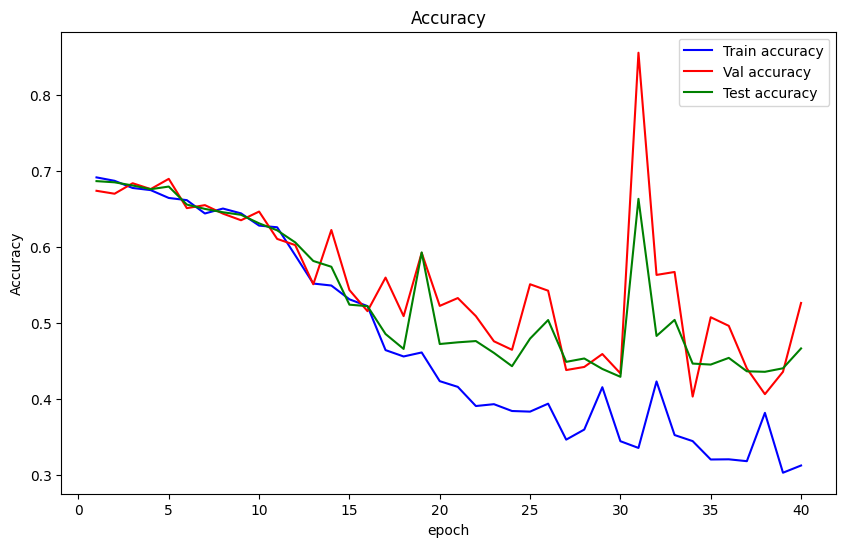

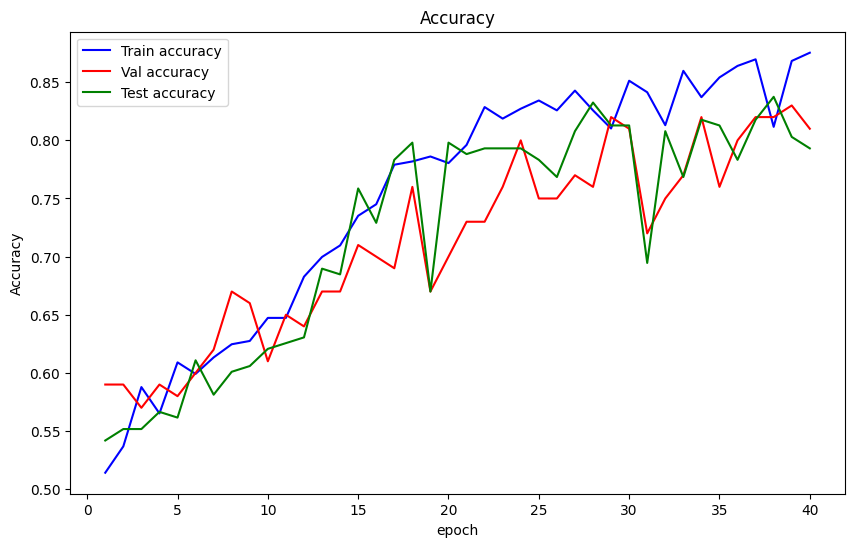



In fold  1
The best validaiton accuracy is:  0.83
Happened at epoch:  39
The corresponding test accuracy 0.8029556650246306
The corresponding test AUC is:  0.8801941747572815




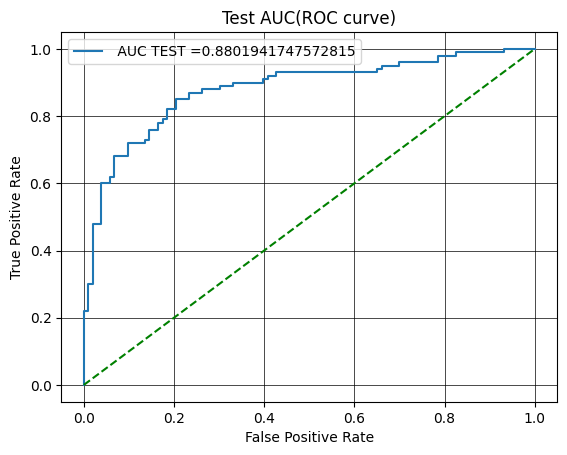

Finish 5-fold training


In [15]:
########################################### Training ################################################
########################################### Training ################################################
########################################### Training ################################################
for fold in range(1, k_fold+1):
  model = GCN(in_c=args.input_dimension, hid_c=args.hidden_dimension, out_c=args.output_dimension, K=args.cheby_order_K, dropout_rate=args.dropout_rate)
  print('  + Number of params: {}'.format(
    sum([p.data.nelement() for p in model.parameters()])))
  model = nn.parallel.DataParallel(model, device_ids=gpu_ids)
  if args.cuda:
    model = model.cuda()
  optimizer = optim.Adam(model.parameters(), lr = args.lr)

  best_validation_accuracy = 0
  Train_accuracy_list =[]
  Train_loss_list = []
  Val_accuracy_list =[]
  Val_loss_list = []
  Test_accuracy_list =[]
  Test_loss_list = []

  for epoch in range(1, args.nEpochs + 1):

    model, train_target, train_out, train_loss, val_target, val_out, val_loss, test_target, test_out, test_prob, test_loss = train(args, model, data[str(fold)], dist_train[str(fold)], dist_validation[str(fold)], dist_test[str(fold)], optimizer)

    train_accuracy = metrics.accuracy_score(train_target, train_out)
    val_accuracy = metrics.accuracy_score(val_target, val_out)
    test_accuracy = metrics.accuracy_score(test_target, test_out)
    Train_accuracy_list.append(train_accuracy)
    Val_accuracy_list.append(val_accuracy)
    Test_accuracy_list.append(test_accuracy)
    Train_loss_list.append(train_loss)
    Val_loss_list.append(val_loss)
    Test_loss_list.append(test_loss)

    if val_accuracy >=best_validation_accuracy:
      best_epoch = epoch
      best_validation_accuracy = val_accuracy
      corresponding_val_out = val_out
      corresponding_test_accuracy = test_accuracy
      corresponding_test_out = test_out
      corresponding_test_prob = test_prob

      print('Save models')
      save_model(model, save_path, 'GCN_'+str(fold))

    print('Train Epoch: ' + str(epoch) + ': train loss : {:.8f}\t train accuracy : {:.8f}\t val accuracy : {:.8f}\t test accuracy : {:.8f}\t'.format(
      train_loss, train_accuracy, val_accuracy, test_accuracy))
  
  if fold == 1:
    all_fold_val_label = val_target
    all_fold_val_out = corresponding_val_out
    all_fold_test_label = test_target
    all_fold_test_out = corresponding_test_out
    all_fold_test_prob = corresponding_test_prob
  else:
    all_fold_val_label = np.concatenate((all_fold_val_label, val_target),axis = 0)
    all_fold_val_out = np.concatenate((all_fold_val_out, corresponding_val_out),axis = 0)
    all_fold_test_label = np.concatenate((all_fold_test_label, test_target),axis = 0)
    all_fold_test_out = np.concatenate((all_fold_test_out, corresponding_test_out),axis = 0)
    all_fold_test_prob = np.concatenate((all_fold_test_prob, corresponding_test_prob),axis = 0)

  x_axis = list(range(1, len(Train_accuracy_list)+1))
  plt.figure(figsize=(10,6))
  plt.plot(x_axis, Train_loss_list, c='b',label='Train accuracy')
  plt.plot(x_axis, Val_loss_list, c='r',label='Val accuracy')
  plt.plot(x_axis, Test_loss_list, c='g',label='Test accuracy')
  plt.title("Accuracy")
  plt.xlabel("epoch")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

  plt.figure(figsize=(10,6))
  plt.plot(x_axis, Train_accuracy_list, c='b',label='Train accuracy')
  plt.plot(x_axis, Val_accuracy_list, c='r',label='Val accuracy')
  plt.plot(x_axis, Test_accuracy_list, c='g',label='Test accuracy')
  plt.title("Accuracy")
  plt.xlabel("epoch")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()


  test_fpr, test_tpr, te_thresholds = roc_curve(test_target, corresponding_test_prob[:,1],pos_label=1)
  test_auc = auc(test_fpr, test_tpr)
  print('\n')
  print('In fold ',str(fold))
  print('The best validaiton accuracy is: ',best_validation_accuracy)
  print('Happened at epoch: ',best_epoch)
  print('The corresponding test accuracy', corresponding_test_accuracy)
  print('The corresponding test AUC is: ',test_auc)
  print('\n')


  plt.grid()
  plt.plot(test_fpr, test_tpr, label=" AUC TEST ="+str(auc(test_fpr, test_tpr)))
  plt.plot([0,1],[0,1],'g--')
  plt.legend()
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("Test AUC(ROC curve)")
  plt.grid(color='black', linestyle='-', linewidth=0.5)
  plt.show()

print('Finish 5-fold training')


The best validation accuracy is  0.83
The corresponding test accuracy is  0.8029556650246306
The corresponding test AUC is:  0.8801941747572815


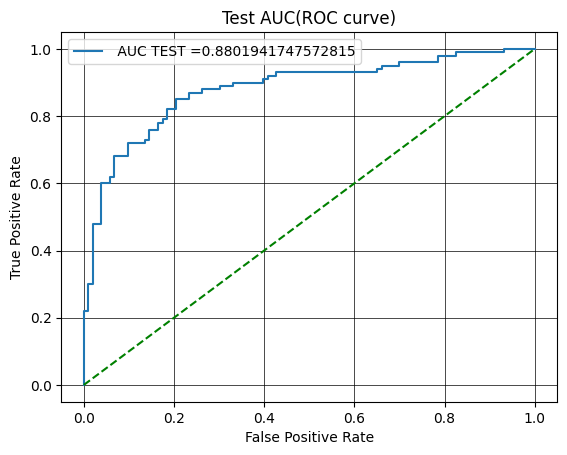

In [16]:
val_accuracy = metrics.accuracy_score(all_fold_val_label, all_fold_val_out)
test_accuracy = metrics.accuracy_score(all_fold_test_label, all_fold_test_out)
test_fpr, test_tpr, te_thresholds = roc_curve(all_fold_test_label, all_fold_test_prob[:,1],pos_label=1)
test_auc = auc(test_fpr, test_tpr)
print('The best validation accuracy is ',val_accuracy)
print('The corresponding test accuracy is ',test_accuracy)
print('The corresponding test AUC is: ',test_auc)
plt.grid()
plt.plot(test_fpr, test_tpr, label=" AUC TEST ="+str(auc(test_fpr, test_tpr)))
plt.plot([0,1],[0,1],'g--')
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test AUC(ROC curve)")
plt.grid(color='black', linestyle='-', linewidth=0.5)
plt.show()